<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Date          6 non-null      object
 1   Store         6 non-null      object
 2   Sales         6 non-null      int64 
 3   Labor_Hours   6 non-null      int64 
 4   Labor_Cost    6 non-null      int64 
 5   Food_Cost     6 non-null      int64 
 6   Transactions  6 non-null      int64 
dtypes: int64(5), object(2)
memory usage: 468.0+ bytes
        Date    Store  Sales  Labor_Hours  Labor_Cost  Food_Cost  \
0 2026-01-01  Store A  12000           95        1800       3400   
1 2026-01-01  Store B  15000          110        2200       4100   
2 2026-01-01  Store C   9800           82        1600       3000   
3 2026-02-01  Store A  13000           97        1850       3500   
4 2026-02-01  Store B  14800          108        2180       4050   

   Transactions  Labor_Percentage  Food_Percentage  Profit

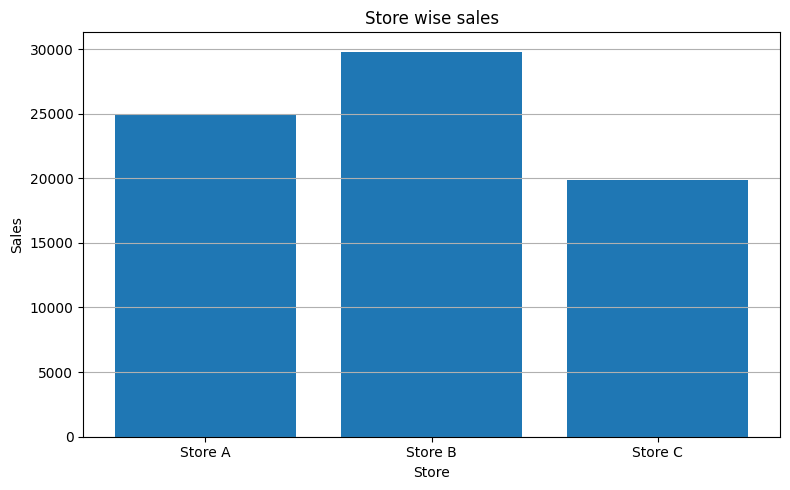

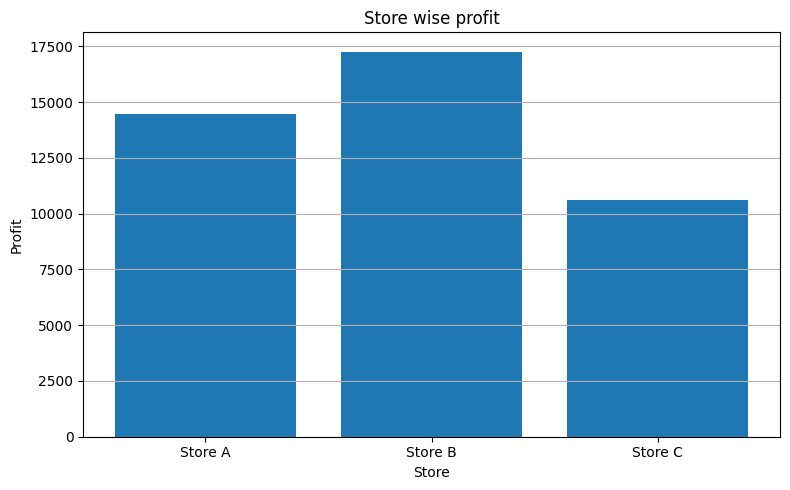

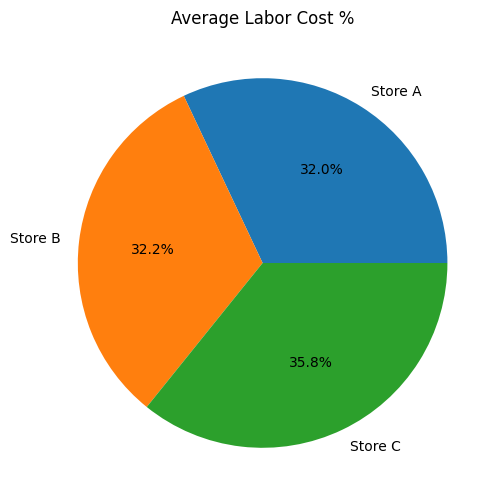

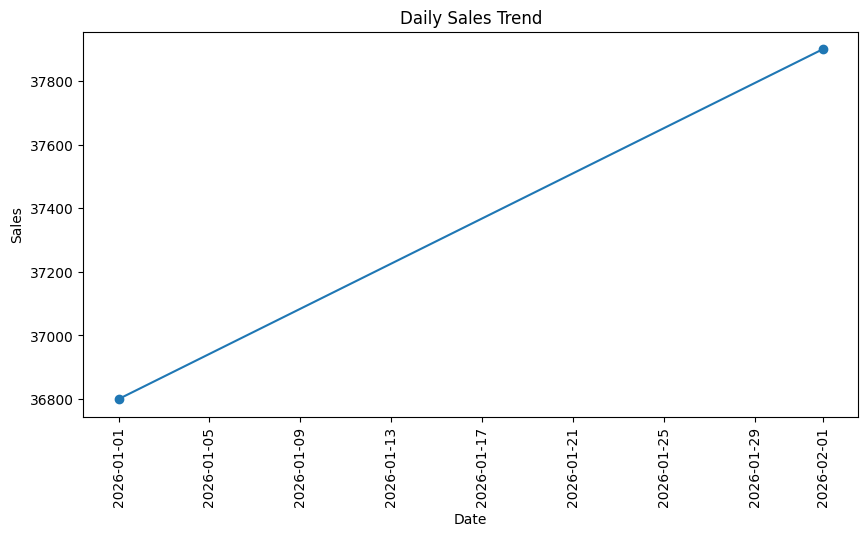

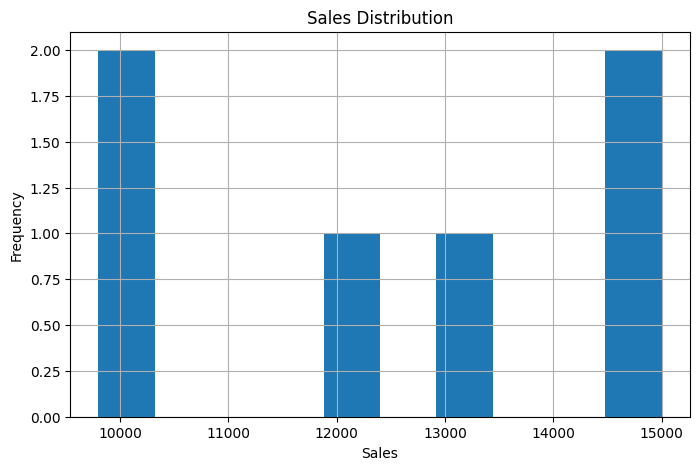

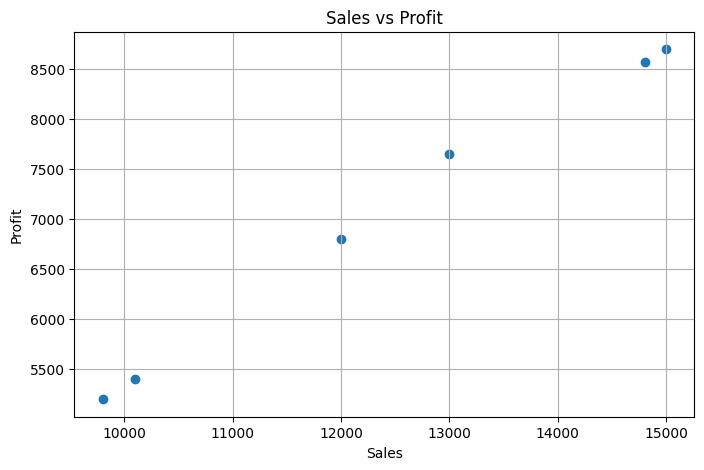

                 Metric    Value
0           Total Sales    74700
1          Total Profit    42320
2       Average Labor %    15.22
3        Average Food %    28.46
4   Highest Sales Store  Store B
5  Highest Profit Store  Store B
                 Sales  Labor_Cost  Food_Cost    Profit  Transactions
Sales         1.000000    0.979888   0.989201  0.996883      0.990329
Labor_Cost    0.979888    1.000000   0.997912  0.961206      0.994938
Food_Cost     0.989201    0.997912   1.000000  0.974601      0.997444
Profit        0.996883    0.961206   0.974601  1.000000      0.977557
Transactions  0.990329    0.994938   0.997444  0.977557      1.000000

Business Insights
---------------------
Highest Sales Store : Store B
Highest Sales : $29,800.00
Highest Profit Store : Store B
Highest Profit : $17,270.00
Average Labor % : 15.22
Average Food Cost % : 28.46
Total Sales : 74700
Total Profit : 42320

Recommendations
---------------------
1. Improve performance of low-sales stores.
2. Monitor store

In [177]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# from google.colab import files

# uploaded = files.upload()

df = pd.read_csv("restaurant_sales.csv")
df.head()

#Explore Data
df.info()
df.describe()
df.shape
df.columns

#Data cleaning
df.isnull().sum()
df.duplicated().sum()
df.drop_duplicates(inplace = True)
df.fillna(0, inplace = True)
df["Date"] = pd.to_datetime(df["Date"])
df.to_csv("restaurant_sales_cleaned.csv", index=False)

#Labor cost %
df["Labor_Percentage"] = round((df["Labor_Cost"] / df["Sales"]) * 100, 2)

#Food coast %
df["Food_Percentage"] = round((df["Food_Cost"] / df["Sales"]) * 100, 2)

#Profit
df["Profit"] = round(df["Sales"] - df["Labor_Cost"] - df["Food_Cost"], 2)

#Profit%
df["Profit_Percentage"] = round((df["Profit"] / df["Sales"]) * 100, 2)

#Average Sale Per Transaction
df["Average_bill"] = round(df["Sales"] / df["Transactions"], 2)

print(df.head())

#Total Sales
print(f"Total Sales: ${df['Sales'].sum():,.2f}")

#Total Profit
print(f"Total Profit: ${df['Profit'].sum():,.2f}")

#Highest Sales Store
sales = df.groupby("Store")["Sales"].sum()
print("Highest Sales Store")
print(sales.idxmax())
print(f"Sales : ${sales.max():,.2f}")



#Highest Profit Store
profit = df.groupby("Store")["Profit"].sum()
print("Highest Profit Store")
print(profit.idxmax())
print(f"Profit :, ${profit.max():,.2f}")

#Average Labor %
print("Average Labor % = ", round(df["Labor_Percentage"].mean(),2))

#Average Food Cost %
print("Average Food Cost % = ", round(df["Food_Percentage"].mean(),2))

#Store-wise Performance
store_performance= df.groupby("Store").agg({
    "Sales": "sum",
    "Labor_Cost": "sum",
    "Food_Cost": "sum",
    "Profit": "sum"
})

print("\nStore-wise Performance")
print(store_performance)
store_performance.to_csv("store_performance.csv")

#Store-wise Sales
sales = df.groupby("Store")["Sales"].sum()

plt.figure(figsize=(8,5))
plt.bar(sales.index, sales.values)
plt.title("Store wise sales")
plt.xlabel("Store")
plt.ylabel("Sales")
plt.grid(axis="y")
plt.tight_layout()
plt.savefig("store_sales.png")
plt.show()


#Profit by Store
profit = df.groupby("Store")["Profit"].sum()
plt.figure(figsize=(8,5))
plt.bar(profit.index, profit.values)
plt.title("Store wise profit")
plt.xlabel("Store")
plt.ylabel("Profit")
plt.grid(axis= "y")
plt.tight_layout()
plt.savefig("store_profit.png")
plt.show()

#Labor Cost %
labor = df.groupby("Store")["Labor_Percentage"].mean()

plt.figure(figsize = (6,6))
plt.pie(labor.values, labels= labor.index, autopct="%1.1f%%")
plt.title("Average Labor Cost %")
plt.savefig("labor_cost_pie.png")
plt.show()

#Sales Trend
daily = df.groupby("Date")["Sales"].sum()
plt.figure(figsize=(10,5))
plt.plot(daily.index, daily.values, marker = "o")
plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.xticks(rotation=90)
plt.savefig("sales_trend.png")
plt.show()

#Sales Distribution
plt.figure(figsize=(8,5))
plt.hist(df["Sales"], bins=10)
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.grid(True)
plt.savefig("sales_distribution.png")
plt.show()

#Sales vs Profit
plt.figure(figsize=(8,5))
plt.scatter(df["Sales"], df["Profit"])
plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.grid(True)
plt.savefig("sales_vs_profit.png")
plt.show()

#Summary
summary = pd.DataFrame({
    "Metric": [
        "Total Sales",
        "Total Profit",
        "Average Labor %",
        "Average Food %",
        "Highest Sales Store",
        "Highest Profit Store"
    ],
    "Value": [
        df["Sales"].sum(),
        df["Profit"].sum(),
        round(df["Labor_Percentage"].mean(),2),
        round(df["Food_Percentage"].mean(),2),
        sales.idxmax(),
        profit.idxmax()
    ]

})

print(summary)

summary.to_csv("summary_report.csv", index=False)

correlation = df[[
    "Sales",
    "Labor_Cost",
    "Food_Cost",
    "Profit",
    "Transactions"
]].corr()

print(correlation)


print("\nBusiness Insights")
print("---------------------")
print("Highest Sales Store :", sales.idxmax())
print(f"Highest Sales : ${sales.max():,.2f}")
print("Highest Profit Store :", profit.idxmax())
print(f"Highest Profit : ${profit.max():,.2f}")
print("Average Labor % :", round(df["Labor_Percentage"].mean(),2))
print("Average Food Cost % :", round(df["Food_Percentage"].mean(),2))
print("Total Sales :", df["Sales"].sum())
print("Total Profit :", df["Profit"].sum())


print("\nRecommendations")
print("---------------------")
print("1. Improve performance of low-sales stores.")
print("2. Monitor stores with high Labor Cost %.")
print("3. Reduce Food Cost by minimizing waste.")
print("4. Increase Average Bill through upselling.")
print("5. Use best-performing store as a benchmark.")